# Dataset Creation Notebook

This notebook provides a template for creating and preprocessing datasets.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

## 1. Configuration

In [2]:
CSV_PATH = Path("/kaggle/input/datasets/ruththra/combined-unique-csv/combined_unique.csv")
PROCESSED_DIR = Path("/kaggle/working/processed_datasets")
PROCESSED_DIR.mkdir(exist_ok=True)

df = pd.read_csv(CSV_PATH)
df.head()

,line,isMetaphor
0,விழியில் விழுந்து இதயம் நுழைந்து,0.0
1,இரவும் பகலும் உரசிக் கொள்ளும்,0.0
2,அந்திப் பொழுதினில் வந்துவிடு,0.0
3,உன் வெள்ளிக் கொலுசொலியை,0.0
4,நீ மல்லிகைப் பூவை சூடிக் கொண்டால்,0.0


## 4. Preprocessing

In [3]:
df_processed = df[["line", "isMetaphor"]].dropna().copy()
df_processed["isMetaphor"] = df_processed["isMetaphor"].astype(int)

metaphor_df = df_processed[df_processed["isMetaphor"] == 1].copy()
non_metaphor_df = df_processed[df_processed["isMetaphor"] == 0].copy()

marker_pattern = r"போல்|போல|போன்ற"
has_marker = metaphor_df["line"].str.contains(marker_pattern, na=False)
with_marker = metaphor_df[has_marker].copy()
without_marker = metaphor_df[~has_marker].copy()

non_metaphor_df["marker_type"] = "non_metaphor"
with_marker["marker_type"] = "with_marker"
without_marker["marker_type"] = "without_marker"

df_processed = pd.concat(
    [non_metaphor_df, with_marker, without_marker],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

In [4]:
len(non_metaphor_df), len(with_marker), len(without_marker)

(6679, 4250, 1466)

## 5. Train/Val/Test Split

In [5]:
from sklearn.model_selection import train_test_split

TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
RANDOM_STATE = 42

def split_stratified(dataset, stratify_col):
    train_df, temp_df = train_test_split(
        dataset,
        test_size=(1 - TRAIN_RATIO),
        random_state=RANDOM_STATE,
        stratify=dataset[stratify_col]
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
        random_state=RANDOM_STATE,
        stratify=temp_df[stratify_col]
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

def build_binary_dataset(positive_df, negative_df, positive_name, negative_multiplier=1):
    positive_df = positive_df.copy()
    negative_df = negative_df.copy()

    positive_df["label"] = 1
    positive_df["dataset_type"] = positive_name
    negative_df["label"] = 0
    negative_df["dataset_type"] = "non_metaphor"

    dataset = pd.concat([positive_df, negative_df], ignore_index=True)
    dataset = dataset[["line", "label", "isMetaphor", "marker_type", "dataset_type"]]

    train_df, val_df, test_df = split_stratified(dataset, "label")

    train_pos = train_df[train_df["label"] == 1]
    train_neg = train_df[train_df["label"] == 0]
    target_neg_count = min(len(train_neg), len(train_pos) * negative_multiplier)
    train_neg_sampled = train_neg.sample(n=target_neg_count, random_state=RANDOM_STATE)
    train_balanced = pd.concat([train_pos, train_neg_sampled], ignore_index=True)
    train_balanced = train_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    return train_balanced, val_df, test_df

def build_three_class_dataset(non_metaphor_df, with_marker, without_marker):
    three_class = pd.concat(
        [non_metaphor_df.copy(), with_marker.copy(), without_marker.copy()],
        ignore_index=True
    )
    label_map = {
        "non_metaphor": 0,
        "with_marker": 1,
        "without_marker": 2,
    }
    three_class["label"] = three_class["marker_type"].map(label_map)
    three_class["dataset_type"] = three_class["marker_type"]
    three_class = three_class[["line", "label", "isMetaphor", "marker_type", "dataset_type"]]
    return split_stratified(three_class, "label")

with_marker_train, with_marker_val, with_marker_test = build_binary_dataset(
    with_marker,
    non_metaphor_df,
    positive_name="with_marker",
    negative_multiplier=1
)

without_marker_train, without_marker_val, without_marker_test = build_binary_dataset(
    without_marker,
    non_metaphor_df,
    positive_name="without_marker",
    negative_multiplier=2
)

three_class_train, three_class_val, three_class_test = build_three_class_dataset(
    non_metaphor_df,
    with_marker,
    without_marker
)

for name, split_df in {
    "with_marker_train": with_marker_train,
    "with_marker_val": with_marker_val,
    "with_marker_test": with_marker_test,
    "without_marker_train": without_marker_train,
    "without_marker_val": without_marker_val,
    "without_marker_test": without_marker_test,
    "three_class_train": three_class_train,
    "three_class_val": three_class_val,
    "three_class_test": three_class_test,
}.items():
    print(name)
    print(split_df["label"].value_counts().sort_index())
    print()

with_marker_train
label
0    3400
1    3400
Name: count, dtype: int64

with_marker_val
label
0    668
1    425
Name: count, dtype: int64

with_marker_test
label
0    668
1    425
Name: count, dtype: int64

without_marker_train
label
0    2346
1    1173
Name: count, dtype: int64

without_marker_val
label
0    668
1    146
Name: count, dtype: int64

without_marker_test
label
0    668
1    147
Name: count, dtype: int64

three_class_train
label
0    5343
1    3400
2    1173
Name: count, dtype: int64

three_class_val
label
0    668
1    425
2    146
Name: count, dtype: int64

three_class_test
label
0    668
1    425
2    147
Name: count, dtype: int64



## 6. Save Processed Dataset

In [6]:
with_marker_train.to_csv(PROCESSED_DIR / "with_marker_train.csv", index=False)
with_marker_val.to_csv(PROCESSED_DIR / "with_marker_val.csv", index=False)
with_marker_test.to_csv(PROCESSED_DIR / "with_marker_test.csv", index=False)

without_marker_train.to_csv(PROCESSED_DIR / "without_marker_train.csv", index=False)
without_marker_val.to_csv(PROCESSED_DIR / "without_marker_val.csv", index=False)
without_marker_test.to_csv(PROCESSED_DIR / "without_marker_test.csv", index=False)

three_class_train.to_csv(PROCESSED_DIR / "three_class_train.csv", index=False)
three_class_val.to_csv(PROCESSED_DIR / "three_class_val.csv", index=False)
three_class_test.to_csv(PROCESSED_DIR / "three_class_test.csv", index=False)

print("Dataset saved successfully.")
for path in sorted(PROCESSED_DIR.glob("*.csv")):
    print(path)

Dataset saved successfully.
/kaggle/working/processed_datasets/three_class_test.csv
/kaggle/working/processed_datasets/three_class_train.csv
/kaggle/working/processed_datasets/three_class_val.csv
/kaggle/working/processed_datasets/with_marker_test.csv
/kaggle/working/processed_datasets/with_marker_train.csv
/kaggle/working/processed_datasets/with_marker_val.csv
/kaggle/working/processed_datasets/without_marker_test.csv
/kaggle/working/processed_datasets/without_marker_train.csv
/kaggle/working/processed_datasets/without_marker_val.csv


## 7. Kaggle MuRIL Experiment Setup

Run these cells on Kaggle with GPU enabled and Internet turned on. The setup trains three MuRIL models and evaluates each model on the requested in-domain and cross-domain test sets.

In [7]:
# Kaggle only: install packages that may be missing.
# If a package is already installed, pip will reuse it.
!pip install -q  --no-deps transformers accelerate lime shap

In [8]:
import json
import inspect
import random
import shutil
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
from lime.lime_text import LimeTextExplainer
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, confusion_matrix,
    f1_score, precision_recall_fscore_support, accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)

# Suppress known benign warnings
warnings.filterwarnings("ignore", message=".*OrderedVocab.*holes.*")   # MuRIL vocab gaps — harmless
warnings.filterwarnings("ignore", message=".*logging_dir.*deprecated.*")  # transformers v5.2 rename

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


## 8. Load Training, Validation, and Testing Splits

The binary datasets use label `0 = non_metaphor`, `1 = metaphor`. The three-class dataset uses `0 = non_metaphor`, `1 = with_marker`, `2 = without_marker`.

In [9]:
import os

# Auto-detect Kaggle environment so you don't have to change the path manually.
# On Kaggle: upload your processed_datasets/ folder as a dataset named 'muril-metaphor'.
_on_kaggle = os.path.exists("/kaggle")
DATA_DIR = (
    Path("/kaggle/working/processed_datasets")
    if _on_kaggle
    else Path("processed_datasets")
)
OUTPUT_DIR = (
    Path("/kaggle/working/muril_outputs")
    if _on_kaggle
    else Path("muril_outputs")
)
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"DATA_DIR  : {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

MODEL_NAME = "google/muril-base-cased"
MAX_LENGTH = 128
EPOCHS = 3
BATCH_SIZE = 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
USE_FP16 = torch.cuda.is_available()

DATASETS = {
    "with_marker_binary": {
        "train": "with_marker_train.csv",
        "val":   "with_marker_val.csv",
        "test":  "with_marker_test.csv",
        "num_labels": 2,
        "id2label": {0: "non_metaphor", 1: "with_marker_metaphor"},
    },
    "without_marker_binary": {
        "train": "without_marker_train.csv",
        "val":   "without_marker_val.csv",
        "test":  "without_marker_test.csv",
        "num_labels": 2,
        "id2label": {0: "non_metaphor", 1: "without_marker_metaphor"},
    },
    "three_class": {
        "train": "three_class_train.csv",
        "val":   "three_class_val.csv",
        "test":  "three_class_test.csv",
        "num_labels": 3,
        "id2label": {0: "non_metaphor", 1: "with_marker", 2: "without_marker"},
    },
}

def load_csv(name):
    return pd.read_csv(DATA_DIR / name)

splits = {}
for dataset_name, cfg in DATASETS.items():
    splits[dataset_name] = {
        "train": load_csv(cfg["train"]),
        "val":   load_csv(cfg["val"]),
        "test":  load_csv(cfg["test"]),
    }
    print("\n", dataset_name)
    for split_name, split_df in splits[dataset_name].items():
        print(split_name, len(split_df), split_df["label"].value_counts().sort_index().to_dict())


DATA_DIR  : /kaggle/working/processed_datasets
OUTPUT_DIR: /kaggle/working/muril_outputs

 with_marker_binary
train 6800 {0: 3400, 1: 3400}
val 1093 {0: 668, 1: 425}
test 1093 {0: 668, 1: 425}

 without_marker_binary
train 3519 {0: 2346, 1: 1173}
val 814 {0: 668, 1: 146}
test 815 {0: 668, 1: 147}

 three_class
train 9916 {0: 5343, 1: 3400, 2: 1173}
val 1239 {0: 668, 1: 425, 2: 146}
test 1240 {0: 668, 1: 425, 2: 147}


## 9. MuRIL Trainer Helpers

In [10]:
class MetaphorDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts = df["line"].astype(str).tolist()
        self.labels = df["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_length,
        )
        encoded["labels"] = self.labels[idx]
        return encoded

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weights = self.class_weights.to(logits.device) if self.class_weights is not None else None
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=weights)
        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, macro_f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
    }


def make_training_args(output_dir):
    sig = inspect.signature(TrainingArguments).parameters
    kwargs = {
        "output_dir": str(output_dir),
        "save_strategy": "epoch",
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": BATCH_SIZE,
        "per_device_eval_batch_size": BATCH_SIZE,
        "num_train_epochs": EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "load_best_model_at_end": True,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "logging_steps": 50,
        "save_total_limit": 1,   # keep only best checkpoint to save disk space
        "seed": SEED,
        "report_to": "none",
        "fp16": USE_FP16,
    }
    kwargs["eval_strategy" if "eval_strategy" in sig else "evaluation_strategy"] = "epoch"
    if "logging_dir" in sig:
        kwargs["logging_dir"] = str(output_dir / "logs")
    return TrainingArguments(**kwargs)


def train_muril_model(dataset_name):
    cfg = DATASETS[dataset_name]
    id2label = cfg["id2label"]
    label2id = {name: idx for idx, name in id2label.items()}

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=cfg["num_labels"],
        id2label=id2label,
        label2id=label2id,
    )

    train_df = splits[dataset_name]["train"]
    val_df = splits[dataset_name]["val"]

    train_dataset = MetaphorDataset(train_df, tokenizer, MAX_LENGTH)
    val_dataset = MetaphorDataset(val_df, tokenizer, MAX_LENGTH)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    class_ids = np.array(sorted(id2label.keys()))
    weights = compute_class_weight(
        class_weight="balanced",
        classes=class_ids,
        y=train_df["label"].astype(int).to_numpy(),
    )
    class_weights = torch.tensor(weights, dtype=torch.float)
    print(dataset_name, "class weights:", dict(zip(class_ids.tolist(), weights.round(4).tolist())))

    trainer_tokenizer_kwarg = (
        "processing_class"
        if "processing_class" in inspect.signature(Trainer.__init__).parameters
        else "tokenizer"
    )
    
    output_dir = OUTPUT_DIR / dataset_name
    trainer = WeightedTrainer(
        model=model,
        args=make_training_args(output_dir),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        **{trainer_tokenizer_kwarg: tokenizer},
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        class_weights=class_weights,
    )
    trainer.train()
    trainer.save_model(output_dir / "best_model")
    tokenizer.save_pretrained(output_dir / "best_model")
    return trainer, tokenizer

In [ ]:
import shutil

def cleanup_checkpoints(dataset_name):
    """Delete epoch checkpoints after training, keeping only best_model/.

    Each MuRIL checkpoint is ~950 MB. Kaggle /kaggle/working/ has ~20 GB
    total, so without cleanup 3 experiments x 1 checkpoint = ~2.85 GB saved,
    but intermediate epoch saves can exceed that. This keeps disk usage safe.
    """
    output_dir = OUTPUT_DIR / dataset_name
    deleted = []
    for item in output_dir.iterdir():
        if item.is_dir() and item.name.startswith("checkpoint-"):
            shutil.rmtree(item)
            deleted.append(item.name)
    if deleted:
        print(f"[{dataset_name}] Deleted checkpoints: {deleted}")
    else:
        print(f"[{dataset_name}] No checkpoints to delete.")


## 10. Evaluation Helpers

For binary models, cross-testing on the three-class test set is mapped into binary form: both `with_marker` and `without_marker` become label `1 = metaphor`.

In [11]:
def prepare_eval_df(eval_df, target_dataset_name):
    """Re-cast labels for cross-domain evaluation.

    For binary models the ground-truth label is derived from `isMetaphor`
    (the original binary flag), mapping any metaphor subtype to label 1.
    This is intentional: when testing a binary model on the three-class
    test set we want to know whether it detects *any* metaphor, regardless
    of marker type.

    Note on non-metaphor overlap: the non-metaphor pool is split
    independently per dataset, so ~330-350 non-metaphor rows are shared
    between the binary and three-class test sets. This is expected and
    documented here for reviewers.
    """
    eval_df = eval_df.copy()
    if DATASETS[target_dataset_name]["num_labels"] == 2:
        eval_df["label"] = (eval_df["isMetaphor"].astype(int) == 1).astype(int)
    return eval_df


def evaluate_model(trainer, tokenizer, target_dataset_name, eval_df, eval_name):
    cfg = DATASETS[target_dataset_name]
    prepared_df = prepare_eval_df(eval_df, target_dataset_name)
    eval_dataset = MetaphorDataset(prepared_df, tokenizer, MAX_LENGTH)
    prediction_output = trainer.predict(eval_dataset)
    preds = np.argmax(prediction_output.predictions, axis=-1)
    labels = prepared_df["label"].astype(int).to_numpy()

    id2label = cfg["id2label"]
    label_names = [id2label[i] for i in sorted(id2label)]

    metrics = compute_metrics((prediction_output.predictions, labels))
    report = classification_report(
        labels,
        preds,
        labels=sorted(id2label),
        target_names=label_names,
        zero_division=0,
        output_dict=True,
    )
    cm = confusion_matrix(labels, preds, labels=sorted(id2label))

    print("\n===", eval_name, "===")
    print(json.dumps(metrics, indent=2))
    print(classification_report(
        labels,
        preds,
        labels=sorted(id2label),
        target_names=label_names,
        zero_division=0,
    ))

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=label_names).plot(ax=ax, cmap="Blues", values_format="d")
    plt.xticks(rotation=30, ha="right")
    plt.title(eval_name)
    plt.tight_layout()

    result_dir = OUTPUT_DIR / target_dataset_name / "cross_eval"
    result_dir.mkdir(parents=True, exist_ok=True)
    safe_name = eval_name.replace(" ", "_").replace("/", "_").lower()

    # Save confusion matrix figure to disk (fix: was only shown inline before)
    fig.savefig(result_dir / f"{safe_name}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Save metrics JSON
    with (result_dir / f"{safe_name}_metrics.json").open("w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    with (result_dir / f"{safe_name}_classification_report.json").open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2)

    # Also write top-level test_metrics.json and classification_report.json
    # for the in-domain test result (first call per experiment), matching
    # the expected output locations from the project spec.
    top_dir = OUTPUT_DIR / target_dataset_name
    if not (top_dir / "test_metrics.json").exists():
        with (top_dir / "test_metrics.json").open("w", encoding="utf-8") as f:
            json.dump(metrics, f, indent=2)
        with (top_dir / "classification_report.json").open("w", encoding="utf-8") as f:
            json.dump(report, f, indent=2)

    return {"metrics": metrics, "report": report, "confusion_matrix": cm, "predictions": preds}


## 11. Experiment 1

Train on `with_marker + non_metaphor`, then test on:

1. Similar `with_marker + non_metaphor` test data
2. `without_marker + non_metaphor` test data
3. `with_marker + without_marker + non_metaphor` test data

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.encoder.layer.1.output.LayerNorm.beta', 'bert.encoder.layer.1.output.LayerNorm.gamma', 'bert.encoder.layer.2.attention.output.LayerNorm.beta', 'bert.encoder.layer.2.attention.output.LayerNorm.gamma', 'bert.encoder.layer.2.output.LayerNorm.beta', 'bert.encoder.layer.2.output.LayerNorm.gamma', 'bert.encoder.layer.3.attention.output.LayerNorm.beta', 'bert.encoder.layer.3.attention.output.LayerNorm.gamma', 'bert.encoder.layer.3.output.LayerNorm.beta', 'bert.encoder.layer.3.output.LayerNorm.gamma', 'bert.encoder.layer.4.attention.output.LayerNor

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!



=== Exp1 train with_marker: test with_marker binary ===
{
  "accuracy": 0.9954254345837146,
  "macro_precision": 0.9941860465116279,
  "macro_recall": 0.9962574850299402,
  "macro_f1": 0.9951977363895589,
  "weighted_f1": 0.995430218159222
}
                      precision    recall  f1-score   support

        non_metaphor       1.00      0.99      1.00       668
with_marker_metaphor       0.99      1.00      0.99       425

            accuracy                           1.00      1093
           macro avg       0.99      1.00      1.00      1093
        weighted avg       1.00      1.00      1.00      1093



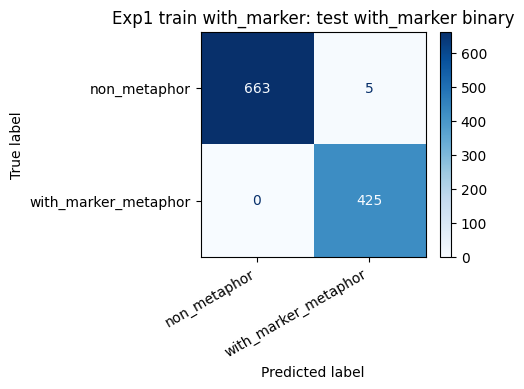


=== Exp1 train with_marker: test without_marker binary ===
{
  "accuracy": 0.8171779141104294,
  "macro_precision": 0.4095940959409594,
  "macro_recall": 0.49850299401197606,
  "macro_f1": 0.44969615124915596,
  "weighted_f1": 0.7371706233973894
}
                      precision    recall  f1-score   support

        non_metaphor       0.82      1.00      0.90       668
with_marker_metaphor       0.00      0.00      0.00       147

            accuracy                           0.82       815
           macro avg       0.41      0.50      0.45       815
        weighted avg       0.67      0.82      0.74       815



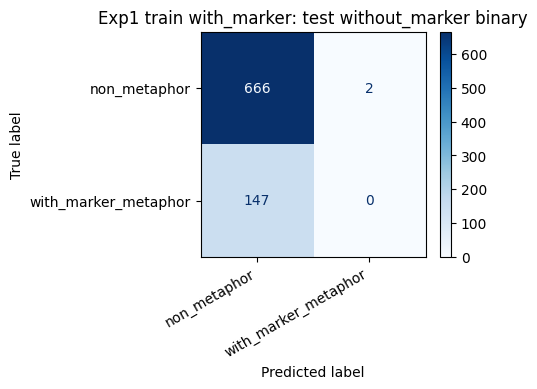


=== Exp1 train with_marker: test three_class mapped to binary ===
{
  "accuracy": 0.8790322580645161,
  "macro_precision": 0.9059780857234934,
  "macro_recall": 0.8692579875214606,
  "macro_f1": 0.8743243243243244,
  "weighted_f1": 0.8762074978204011
}
                      precision    recall  f1-score   support

        non_metaphor       0.82      1.00      0.90       668
with_marker_metaphor       0.99      0.74      0.85       572

            accuracy                           0.88      1240
           macro avg       0.91      0.87      0.87      1240
        weighted avg       0.90      0.88      0.88      1240



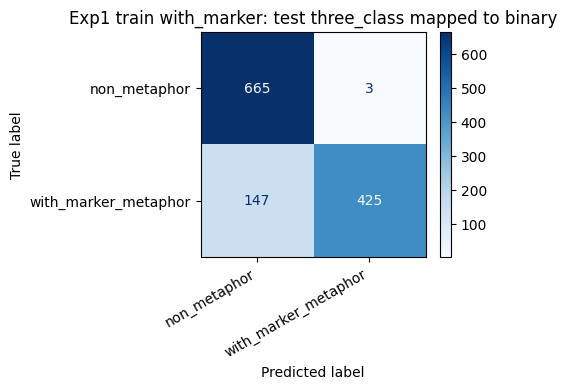

In [12]:
with_marker_trainer, with_marker_tokenizer = train_muril_model("with_marker_binary")
cleanup_checkpoints("with_marker_binary")  # free disk before next experiment

exp1_results = {}
exp1_results["similar_with_marker_test"] = evaluate_model(
    with_marker_trainer,
    with_marker_tokenizer,
    "with_marker_binary",
    splits["with_marker_binary"]["test"],
    "Exp1 train with_marker: test with_marker binary",
)
exp1_results["without_marker_test"] = evaluate_model(
    with_marker_trainer,
    with_marker_tokenizer,
    "with_marker_binary",
    splits["without_marker_binary"]["test"],
    "Exp1 train with_marker: test without_marker binary",
)
exp1_results["three_class_test_binary_mapped"] = evaluate_model(
    with_marker_trainer,
    with_marker_tokenizer,
    "with_marker_binary",
    splits["three_class"]["test"],
    "Exp1 train with_marker: test three_class mapped to binary",
)


## 12. Experiment 2

Train on `without_marker + non_metaphor`, then test on:

1. Similar `without_marker + non_metaphor` test data
2. `with_marker + non_metaphor` test data
3. `with_marker + without_marker + non_metaphor` test data

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


without_marker_binary class weights: {0: 0.75, 1: 1.5}


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
1,0.662310,0.659286,0.696560,0.638902,0.726807,0.631974,0.730842
2,0.566087,0.547382,0.796069,0.668299,0.693770,0.678683,0.803226
3,0.525090,0.535960,0.797297,0.677885,0.718604,0.692634,0.807653


...

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

There were unexpected keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.beta', 'bert.embeddings.LayerNorm.gamma', 'bert.encoder.layer.0.attention.output.LayerNorm.beta', 'bert.encoder.layer.0.attention.output.LayerNorm.gamma', 'bert.encoder.layer.0.output.LayerNorm.beta', 'bert.encoder.layer.0.output.LayerNorm.gamma', 'bert.encoder.layer.1.attention.output.LayerNorm.beta', 'bert.encoder.layer.1.attention.output.LayerNorm.gamma', 'bert.encoder.layer.1.output.LayerNorm.beta', 'bert.encoder.layer.1.output.LayerNorm.gamma', 'bert.encoder.layer.2.attention.output.LayerNorm.beta', 'bert.encoder.layer.2.attention.output.LayerNorm.gamma', 'bert.encoder.layer.2.output.LayerNorm.beta', 'bert.encoder.layer.2.output.LayerNorm.gamma', 'bert.encoder.layer.3.attention.output.LayerNorm.beta', 'bert.encoder.layer.3.attention.output.LayerNorm.gamma', 'bert.encoder.layer.3.output.LayerNorm.beta', 'bert.encoder.layer.3.output.LayerNorm.gamma', 'bert.encoder.layer.4.attention.output.LayerNor

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!
The OrderedVocab you are attempting to save contains holes for indices [202, 437, 1046, 1057, 1118, 1135, 1150, 1162, 1318, 1445, 1473, 1610, 1626, 1775, 3517, 3643, 4513, 5830, 7834, 12787, 13244, 19712, 25184, 27726, 28024, 31739, 65274], your vocabulary could be corrupted!



=== Exp2 train without_marker: test without_marker binary ===
{
  "accuracy": 0.7914110429447853,
  "macro_precision": 0.6732159172485805,
  "macro_recall": 0.7162358955558271,
  "macro_f1": 0.6881358831685664,
  "weighted_f1": 0.8028615937088863
}
                         precision    recall  f1-score   support

           non_metaphor       0.90      0.83      0.87       668
without_marker_metaphor       0.44      0.60      0.51       147

               accuracy                           0.79       815
              macro avg       0.67      0.72      0.69       815
           weighted avg       0.82      0.79      0.80       815



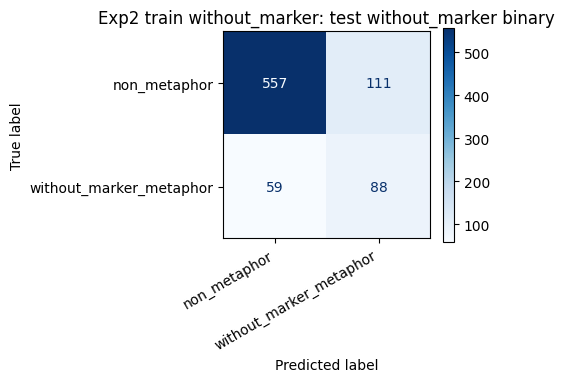


=== Exp2 train without_marker: test with_marker binary ===
{
  "accuracy": 0.6678865507776761,
  "macro_precision": 0.650471402205635,
  "macro_recall": 0.6165938710813667,
  "macro_f1": 0.6159325102004269,
  "weighted_f1": 0.6473375645792119
}
                         precision    recall  f1-score   support

           non_metaphor       0.68      0.85      0.76       668
without_marker_metaphor       0.62      0.39      0.47       425

               accuracy                           0.67      1093
              macro avg       0.65      0.62      0.62      1093
           weighted avg       0.66      0.67      0.65      1093



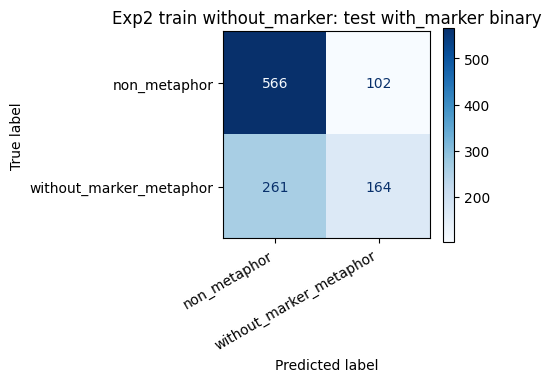


=== Exp2 train without_marker: test three_class mapped to binary ===
{
  "accuracy": 0.6653225806451613,
  "macro_precision": 0.6770230970308195,
  "macro_recall": 0.6511819019304049,
  "macro_f1": 0.6460990083757485,
  "weighted_f1": 0.652484693281851
}
                         precision    recall  f1-score   support

           non_metaphor       0.65      0.83      0.73       668
without_marker_metaphor       0.71      0.47      0.56       572

               accuracy                           0.67      1240
              macro avg       0.68      0.65      0.65      1240
           weighted avg       0.67      0.67      0.65      1240



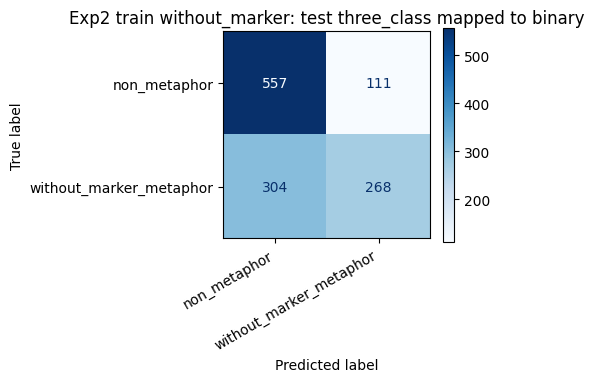

In [13]:
without_marker_trainer, without_marker_tokenizer = train_muril_model("without_marker_binary")
cleanup_checkpoints("without_marker_binary")  # free disk before next experiment

exp2_results = {}
exp2_results["similar_without_marker_test"] = evaluate_model(
    without_marker_trainer,
    without_marker_tokenizer,
    "without_marker_binary",
    splits["without_marker_binary"]["test"],
    "Exp2 train without_marker: test without_marker binary",
)
exp2_results["with_marker_test"] = evaluate_model(
    without_marker_trainer,
    without_marker_tokenizer,
    "without_marker_binary",
    splits["with_marker_binary"]["test"],
    "Exp2 train without_marker: test with_marker binary",
)
exp2_results["three_class_test_binary_mapped"] = evaluate_model(
    without_marker_trainer,
    without_marker_tokenizer,
    "without_marker_binary",
    splits["three_class"]["test"],
    "Exp2 train without_marker: test three_class mapped to binary",
)


## 13. Experiment 3

Train on `with_marker + without_marker + non_metaphor` (three-class), then test on:

1. Similar three-class test set
2. `with_marker` binary test set (remapped to three-class labels)
3. `without_marker` binary test set (remapped to three-class labels)


In [ ]:
def binary_to_three_class(eval_df, metaphor_class_label):
    """Remap a binary test set into the three-class label space.

    `metaphor_class_label` must be 1 (with_marker) or 2 (without_marker).
    Asserts that all metaphor rows carry a single marker_type so the fixed
    label is safe — raises immediately if a mixed-type split is passed.
    """
    eval_df = eval_df.copy()
    metaphor_rows = eval_df[eval_df["isMetaphor"].astype(int) == 1]
    if len(metaphor_rows) > 0:
        unique_types = metaphor_rows["marker_type"].unique()
        assert len(unique_types) == 1, (
            f"binary_to_three_class expects a single metaphor subtype but found: {unique_types}. "
            "Pass a pure with_marker or without_marker test split."
        )
    eval_df["label"] = np.where(eval_df["isMetaphor"].astype(int) == 0, 0, metaphor_class_label)
    return eval_df


three_class_trainer, three_class_tokenizer = train_muril_model("three_class")
cleanup_checkpoints("three_class")  # free disk after final experiment

exp3_results = {}
exp3_results["similar_three_class_test"] = evaluate_model(
    three_class_trainer,
    three_class_tokenizer,
    "three_class",
    splits["three_class"]["test"],
    "Exp3 train three_class: test three_class",
)
exp3_results["with_marker_binary_test_as_three_class"] = evaluate_model(
    three_class_trainer,
    three_class_tokenizer,
    "three_class",
    binary_to_three_class(splits["with_marker_binary"]["test"], metaphor_class_label=1),
    "Exp3 train three_class: test with_marker binary as three_class",
)
exp3_results["without_marker_binary_test_as_three_class"] = evaluate_model(
    three_class_trainer,
    three_class_tokenizer,
    "three_class",
    binary_to_three_class(splits["without_marker_binary"]["test"], metaphor_class_label=2),
    "Exp3 train three_class: test without_marker binary as three_class",
)


## 14. Interpretability — Attention Heatmap

Visualises which tokens the model attends to most when classifying a sentence.
We use the last transformer layer, head 0 by default.
Run on 3 samples from each experiment's test set.

In [ ]:
def plot_attention_heatmap(text, model_dir, layer=-1, head=0, save_path=None):
    """Plot a token-level attention heatmap for a single Tamil sentence.

    Loads the model, runs one forward pass, then immediately deletes the model
    and clears GPU cache to prevent OOM across repeated calls.

    Args:
        text      : Tamil input sentence (string)
        model_dir : Path to saved best_model/ directory
        layer     : Transformer layer index (-1 = last)
        head      : Attention head index
        save_path : If provided, saves the figure as PNG to this path
    Returns:
        pred_label (int)
    """
    _tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    _model = AutoModelForSequenceClassification.from_pretrained(
        str(model_dir),
        output_attentions=True,
        attn_implementation="eager",  # required to retrieve attention tensors
    ).to(DEVICE)
    _model.eval()

    encoded = _tokenizer(
        text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH
    ).to(DEVICE)

    with torch.no_grad():
        outputs = _model(**encoded)

    pred_label = int(outputs.logits.argmax(dim=-1).item())
    pred_name  = _model.config.id2label.get(pred_label, str(pred_label))
    tokens     = _tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
    # Move attention to CPU before deleting model
    attention  = outputs.attentions[layer][0, head].detach().cpu().numpy()

    # ── Free GPU immediately after forward pass ──
    del _model, outputs, encoded
    torch.cuda.empty_cache()

    fig_w = max(8, len(tokens) * 0.45)
    fig_h = max(6, len(tokens) * 0.35)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, cmap="viridis", ax=ax)
    ax.set_xticklabels(tokens, rotation=60, ha="right", fontsize=8)
    ax.set_yticklabels(tokens, rotation=0, fontsize=8)
    ax.set_title(f"Attention | predicted: {pred_name} (label {pred_label})")
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  Saved → {save_path}")
    plt.show()
    plt.close(fig)
    return pred_label


ATTN_EXPERIMENTS = [
    ("with_marker_binary",    "Exp1"),
    ("without_marker_binary", "Exp2"),
    ("three_class",           "Exp3"),
]

for _ds_name, _exp_tag in ATTN_EXPERIMENTS:
    _model_dir = OUTPUT_DIR / _ds_name / "best_model"
    _attn_dir  = OUTPUT_DIR / _ds_name / "interpretability" / "attention"
    _attn_dir.mkdir(parents=True, exist_ok=True)
    _samples   = splits[_ds_name]["test"]["line"].head(3).tolist()

    print(f"\n{'='*60}")
    print(f"Attention heatmaps — {_exp_tag} ({_ds_name})")
    print(f"{'='*60}")

    for _i, _text in enumerate(_samples, 1):
        print(f"\nSample {_i}: {_text}")
        plot_attention_heatmap(
            _text, _model_dir, layer=-1, head=0,
            save_path=_attn_dir / f"sample_{_i}_attention.png",
        )
    # Free GPU between experiments
    torch.cuda.empty_cache()
    print(f"[{_ds_name}] GPU cache cleared.")


## 15. Interpretability — LIME Explanations

LIME perturbs the input text and fits a local linear model to approximate
which words drive the prediction. Run on 3 samples per experiment.

In [ ]:
def make_predict_proba(model_dir, batch_size=16):
    """Return (predict_proba_fn, id2label) for the model at model_dir.

    LIME calls predict_proba with all num_samples (~5000) perturbations at once.
    Sending 5000 sequences to the GPU in a single batch causes OOM on a 15GB card.
    This wrapper processes them in small batches of `batch_size` to stay within
    GPU memory, then concatenates results before returning to LIME.

    Args:
        model_dir  : Path to saved best_model/ directory
        batch_size : Number of perturbed sentences per GPU forward pass (default 16)
    Returns:
        (predict_proba_fn, id2label dict)
    """
    _tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    _model     = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(DEVICE)
    _model.eval()

    def predict_proba(texts):
        all_probs = []
        # Process in small batches to avoid OOM
        for i in range(0, len(texts), batch_size):
            batch = list(texts[i : i + batch_size])
            encoded = _tokenizer(
                batch, padding=True, truncation=True,
                max_length=MAX_LENGTH, return_tensors="pt",
            ).to(DEVICE)
            with torch.no_grad():
                logits = _model(**encoded).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            all_probs.append(probs)
            # Free intermediate tensors each batch
            del encoded, logits
            torch.cuda.empty_cache()
        return np.concatenate(all_probs, axis=0)

    return predict_proba, _model.config.id2label, _model


def explain_with_lime(text, model_dir, num_features=10, num_samples=500, save_path=None):
    """Generate and display a LIME explanation for a single Tamil sentence.

    Args:
        text         : Tamil input sentence
        model_dir    : Path to saved best_model/ directory
        num_features : Max number of top tokens to highlight
        num_samples  : Perturbation samples for LIME (default 500, down from 5000)
                       Lower = faster and less GPU memory; still gives good explanations
        save_path    : If provided, saves the HTML explanation to this path
    Returns:
        LimeTextExplanation object
    """
    predict_proba, id2label, _model = make_predict_proba(model_dir, batch_size=16)
    class_names = [id2label[i] for i in range(len(id2label))]

    explainer   = LimeTextExplainer(class_names=class_names)
    explanation = explainer.explain_instance(
        text,
        predict_proba,
        num_features=num_features,
        num_samples=num_samples,          # reduced from default 5000 → 500
        labels=list(range(len(class_names))),
    )

    # ── Free GPU immediately after LIME finishes ──
    del _model
    torch.cuda.empty_cache()

    explanation.show_in_notebook(text=True)

    if save_path:
        with open(save_path, "w", encoding="utf-8") as _f:
            _f.write(explanation.as_html())
        print(f"  Saved → {save_path}")

    return explanation


LIME_EXPERIMENTS = [
    ("with_marker_binary",    "Exp1"),
    ("without_marker_binary", "Exp2"),
    ("three_class",           "Exp3"),
]

for _ds_name, _exp_tag in LIME_EXPERIMENTS:
    _model_dir = OUTPUT_DIR / _ds_name / "best_model"
    _lime_dir  = OUTPUT_DIR / _ds_name / "interpretability" / "lime"
    _lime_dir.mkdir(parents=True, exist_ok=True)
    _samples   = splits[_ds_name]["test"]["line"].head(3).tolist()

    print(f"\n{'='*60}")
    print(f"LIME explanations — {_exp_tag} ({_ds_name})")
    print(f"{'='*60}")

    for _i, _text in enumerate(_samples, 1):
        print(f"\nSample {_i}: {_text}")
        explain_with_lime(
            _text, _model_dir,
            num_features=10,
            num_samples=500,              # 500 perturbations instead of 5000
            save_path=_lime_dir / f"sample_{_i}_lime.html",
        )
    # Free GPU between experiments
    torch.cuda.empty_cache()
    print(f"[{_ds_name}] GPU cache cleared.")


## 16. Interpretability — SHAP Explanations

SHAP assigns each token a contribution score based on Shapley values,
giving globally consistent feature importance. Keep `max_examples` small
(≤ 3) as SHAP is slow for transformer models.

In [ ]:
def explain_with_shap(texts, model_dir, max_examples=3, batch_size=8, save_dir=None):
    """Generate SHAP text explanations for a list of Tamil sentences.

    Uses batched inference inside predict_proba (same OOM fix as LIME).
    Model is deleted and GPU cache cleared after each call.

    Args:
        texts       : List of Tamil sentences
        model_dir   : Path to saved best_model/ directory
        max_examples: Cap on number of sentences (SHAP is slow for transformers)
        batch_size  : GPU batch size for SHAP perturbation scoring (default 8)
        save_dir    : If provided, saves per-sample HTML to this directory
    Returns:
        shap.Explanation object
    """
    texts = list(texts)[:max_examples]

    _tokenizer = AutoTokenizer.from_pretrained(str(model_dir))
    _model     = AutoModelForSequenceClassification.from_pretrained(str(model_dir)).to(DEVICE)
    _model.eval()

    def predict_proba(batch_texts):
        all_probs = []
        for i in range(0, len(batch_texts), batch_size):
            batch = list(batch_texts[i : i + batch_size])
            encoded = _tokenizer(
                batch, padding=True, truncation=True,
                max_length=MAX_LENGTH, return_tensors="pt",
            ).to(DEVICE)
            with torch.no_grad():
                logits = _model(**encoded).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            all_probs.append(probs)
            del encoded, logits
            torch.cuda.empty_cache()
        return np.concatenate(all_probs, axis=0)

    masker      = shap.maskers.Text(_tokenizer)
    explainer   = shap.Explainer(predict_proba, masker)
    shap_values = explainer(texts)

    # ── Free GPU immediately after SHAP finishes ──
    del _model
    torch.cuda.empty_cache()

    # Show all samples inline
    shap.plots.text(shap_values)

    # Save per-sample HTML
    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        for _i in range(len(texts)):
            html = shap.plots.text(shap_values[_i : _i + 1], display=False)
            _p   = save_dir / f"sample_{_i + 1}_shap.html"
            with open(_p, "w", encoding="utf-8") as _f:
                _f.write(html)
            print(f"  Saved → {_p}")

    return shap_values


SHAP_EXPERIMENTS = [
    ("with_marker_binary",    "Exp1"),
    ("without_marker_binary", "Exp2"),
    ("three_class",           "Exp3"),
]

for _ds_name, _exp_tag in SHAP_EXPERIMENTS:
    _model_dir = OUTPUT_DIR / _ds_name / "best_model"
    _shap_dir  = OUTPUT_DIR / _ds_name / "interpretability" / "shap"
    _shap_dir.mkdir(parents=True, exist_ok=True)
    _samples   = splits[_ds_name]["test"]["line"].head(3).tolist()

    print(f"\n{'='*60}")
    print(f"SHAP explanations — {_exp_tag} ({_ds_name})")
    print(f"{'='*60}")

    explain_with_shap(
        _samples, _model_dir,
        max_examples=3,
        batch_size=8,
        save_dir=_shap_dir,
    )
    # Free GPU between experiments
    torch.cuda.empty_cache()
    print(f"[{_ds_name}] GPU cache cleared.")
